# study-design-overview — interactive validation

**Recipe:** `genomics/study-design-overview`
**Fixture:** GSE192391 sample metadata — 30 samples x 11 columns (`sample_metadata.csv`).
Exercises **Steps 1-3** (metadata-only). **Step 4 (PCA-by-factor) is NOT exercised** —
it requires an expression matrix, which this metadata-only fixture does not provide.

Each step below is the recipe code **verbatim**, with the fixture path substituted for
`"/path/to/sample_metadata.csv"`. After each figure save, the PNG is embedded inline so
the rendered HTML shows figures.

## Setup — chdir into `outputs/`, define inline embed helper

In [1]:
import os
os.makedirs("outputs", exist_ok=True)
os.chdir("outputs")
from IPython.display import Image, display
FIXTURE = "/tmp/aba-recipe-pack/recipes/genomics/study-design-overview/test-study-design-overview/sample_metadata.csv"
print("cwd:", os.getcwd())
print("fixture:", FIXTURE)

cwd: /tmp/aba-recipe-pack/recipes/genomics/study-design-overview/test-study-design-overview/outputs
fixture: /tmp/aba-recipe-pack/recipes/genomics/study-design-overview/test-study-design-overview/sample_metadata.csv


## Install (recipe Install block — verbatim)

In [2]:
# dython supplies the unified mixed-type association matrix (bias-corrected
# Cramér's V / correlation ratio / Spearman) and the clustered heatmap. patsy
# (ships with statsmodels) builds the design matrix for the rank/aliasing check.
# scipy, scikit-learn, pandas, numpy, matplotlib, seaborn are in the base stack.
try:
    import dython, patsy  # noqa: F401
except Exception:
    pass  # call ensure_capability(name="dython") once; patsy comes via statsmodels
print("dython", dython.__version__, "| patsy", patsy.__version__)

dython 0.7.12 | patsy 1.0.2


## Step 1 — Load and type the sample metadata

Expect: 11 columns classified. GSM/title -> drop:id-like; patient id -> drop:high-cardinality;
tissue/cell type -> drop:constant; age -> continuous; disease state/status/Sex/ethnicity/time -> categorical.
Kept-factor line: 6 factors (5 categorical, 1 continuous) across 30 samples.

In [3]:
import pandas as pd, numpy as np

# Rows = samples, columns = candidate factors. If you already have this in memory
# (e.g. from a GEO fetch), use that DataFrame directly and skip the read.
meta = pd.read_csv(FIXTURE)

# Classify each column. GEO/SRA metadata arrives as STRINGS, so numeric factors
# (age, RIN) look like objects — test whether a column PARSES as numeric, don't
# trust the dtype; and an ID-NAMED column (patient id, donor) is a label, never a
# continuous measurement, even when coded with numbers. Heuristics (override per
# study where wrong):
#   n_unique <= 1                  -> drop:constant   (no design information)
#   n_unique == n_samples          -> drop:id-like    (a sample identifier)
#   pct_missing > 50%              -> drop:sparse      (too incomplete to use)
#   numeric (and not id-named) AND n_unique>10 -> continuous   (age, RIN, date)
#   categorical with n_unique > n/2 -> drop:high-cardinality   (near-id grouping,
#       e.g. patient/subject — every patient-level attribute is trivially nested
#       within it, which would flood the verdict with meaningless aliases; set it
#       aside by default, re-include only for an explicit repeated-measures model)
#   otherwise                      -> categorical
import re
ID_NAME = re.compile(r"\b(id|ids|patient|subject|donor|sample|accession|gsm|srr|barcode|uuid)\b", re.I)
def parses_numeric(s):
    return pd.to_numeric(s, errors="coerce").notna().mean() >= 0.8   # ≥80% are numbers
n = len(meta)
rows = []
for c in meta.columns:
    nun  = int(meta[c].nunique(dropna=True))
    miss = float(meta[c].isna().mean())
    is_num = (not ID_NAME.search(c)) and (pd.api.types.is_numeric_dtype(meta[c]) or parses_numeric(meta[c]))
    if   nun <= 1:              role = "drop:constant"
    elif nun >= n:             role = "drop:id-like"
    elif miss > 0.5:           role = "drop:sparse"
    elif is_num and nun > 10:  role = "continuous"
    elif nun > n / 2:          role = "drop:high-cardinality"
    else:                      role = "categorical"
    rows.append(dict(column=c, dtype=str(meta[c].dtype), n_unique=nun,
                     pct_missing=round(100*miss, 1), suggested=role))
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

# Keep informative factors; coerce continuous to numeric, categoricals to plain
# str. Use astype(str), NOT astype("string") — dython's NaN handling rejects the
# pandas nullable 'string' dtype (it silently returns 0 associations).
factors  = summary.loc[summary.suggested.isin(["categorical", "continuous"]), "column"].tolist()
num_cols = summary.loc[summary.suggested == "continuous", "column"].tolist()
cat_cols = [c for c in factors if c not in num_cols]
design = meta[factors].copy()
design[num_cols] = design[num_cols].apply(pd.to_numeric, errors="coerce")
for c in cat_cols:
    design[c] = design[c].astype(str)
print(f"\nUsing {len(factors)} factors ({len(cat_cols)} categorical, "
      f"{len(num_cols)} continuous) across {n} samples")

       column  dtype  n_unique  pct_missing             suggested
          GSM object        30          0.0          drop:id-like
        title object        30          0.0          drop:id-like
   patient id object        18          0.0 drop:high-cardinality
       tissue object         1          0.0         drop:constant
    cell type object         1          0.0         drop:constant
disease state object         2          0.0           categorical
       status object         3          0.0           categorical
          age  int64        15          0.0            continuous
          Sex object         2          0.0           categorical
    ethnicity object         2          0.0           categorical
         time object         2         20.0           categorical

Using 6 factors (5 categorical, 1 continuous) across 30 samples


## Step 2 — Clustered mixed-type association heatmap

Expect: `association_heatmap.png` (clustermap, Reds, annotated). Top pairs:
disease state x time ~0.98, disease state x status ~0.87, status x time ~0.60.

In [4]:
from dython.nominal import associations
import seaborn as sns, matplotlib.pyplot as plt

# cat×cat = bias-corrected Cramér's V; cat×continuous = correlation ratio η;
# continuous×continuous = Spearman ρ. Compute the matrix with dython, then render
# with seaborn.clustermap so correlated factor groups form visible blocks. (Use
# clustermap, NOT dython's clustering=True — that path calls sch.distance.pdist
# and is broken against recent scipy.) dython RETURNS A DICT — the matrix is
# res["corr"] (NOT res.corr).
res = associations(
    design,
    nominal_columns=cat_cols,            # be explicit; 'auto' can mis-detect numeric-coded categories
    nom_nom_assoc="cramer",
    nom_num_assoc="correlation_ratio",
    num_num_assoc="spearman",            # robust default for metadata (age, RIN, date)
    cramers_v_bias_correction=True,      # essential for small / unbalanced GEO cohorts
    nan_strategy="drop_samples",         # don't let NaN become a phantom category
    compute_only=True,                   # we render the heatmap ourselves (next)
)
assoc = res["corr"].astype(float)        # the N×N association matrix (DataFrame)
mag = assoc.abs().fillna(0)              # display magnitude (|ρ| for continuous pairs), in [0,1]

g = sns.clustermap(mag, cmap="Reds", vmin=0, vmax=1, annot=True, fmt=".2f",
                   figsize=(9, 8), dendrogram_ratio=0.12,
                   cbar_kws={"label": "association (V / η / |ρ|)"})
g.figure.suptitle("Factor–factor association (clustered)", y=1.02)
g.savefig("association_heatmap.png", dpi=120); plt.close("all")

# Rank the off-diagonal pairs — the ones to scrutinize.
m = mag.copy(); np.fill_diagonal(m.values, np.nan)
pairs = (m.stack().reset_index()
           .rename(columns={"level_0": "factor_a", "level_1": "factor_b", 0: "assoc"}))
pairs = pairs[pairs.factor_a < pairs.factor_b].sort_values("assoc", ascending=False)
print(pairs.head(10).to_string(index=False))

     factor_a      factor_b    assoc
disease state          time 0.981981
disease state        status 0.874706
       status          time 0.599739
          Sex        status 0.403488
          Sex          time 0.240906
          Sex disease state 0.192638
          Sex           age 0.136891
          age     ethnicity 0.121259
          age        status 0.082946
          age          time 0.022216


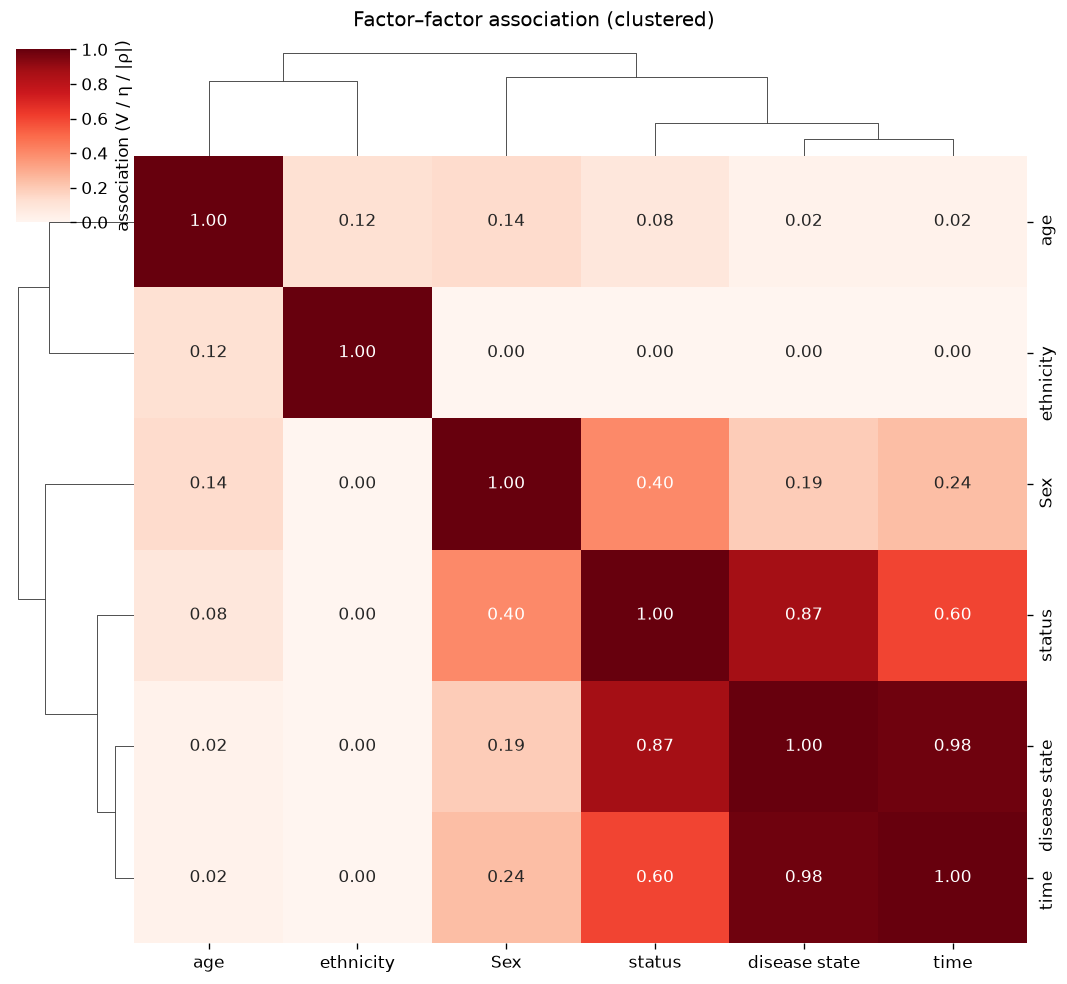

In [5]:
display(Image("association_heatmap.png"))

## Step 3 — Confounding / aliasing verdict

Expect: `confounding_report.csv`, then `design_balance.png`. Verdict ~ 12 GREEN / 2 RED / 1 AMBER.
RED: disease state x time (aliased), status x time. AMBER: disease state x status. No technical
factors in this study, so every pair is bio x bio.

In [6]:
import numpy as np, pandas as pd, patsy, re
from itertools import combinations

# Name heuristic for technical factors — EDIT `technical` directly if the study
# uses non-obvious names; it is the fallback, not a guarantee. (Many GEO studies
# expose no technical column at all — then every pair is bio×bio, which is fine.)
TECH = re.compile(r"batch|run|lane|plate|platform|date|librar|flow.?cell|chip|machine|center|site|seq", re.I)
technical = [c for c in factors if TECH.search(c)]
def role(c): return "tech" if c in technical else "bio"
print("technical factors detected:", technical or "(none — edit `technical` if any apply)")

# Association magnitude from Step 2, keyed by the sorted pair.
assoc_of = {tuple(sorted([r.factor_a, r.factor_b])): float(r.assoc) for r in pairs.itertuples()}

def verdict(a, b):
    d = design[[a, b]].dropna()
    # rank < ncol  ⇔  one factor is a deterministic function of the other (aliased)
    X = patsy.dmatrix(f"Q('{a}') + Q('{b}')", d, return_type="dataframe")
    rank, ncol = int(np.linalg.matrix_rank(X.values)), X.shape[1]
    strength = assoc_of.get(tuple(sorted([a, b])), float("nan"))
    # empty design cells are only meaningful between two categoricals (a crosstab
    # over a continuous factor is degenerate) — reported as info, not the trigger.
    cat_pair = (a in cat_cols) and (b in cat_cols)
    empty = int((pd.crosstab(d[a], d[b]).values == 0).sum()) if cat_pair else None
    if   rank < ncol:        flag = "RED"      # aliased — effects inseparable
    elif strength >= 0.5:    flag = "AMBER"    # strong but separable — partial confounding
    else:                    flag = "GREEN"    # estimable, weak association
    return dict(factor_a=a, factor_b=b, pair_type="×".join(sorted([role(a), role(b)])),
                assoc=round(strength, 2), n=len(d), rank=rank, ncol=ncol,
                empty_cells=empty, flag=flag)

report = pd.DataFrame([verdict(a, b) for a, b in combinations(factors, 2)])
# Danger order: RED→AMBER→GREEN; biological×technical ahead of same-type; then assoc.
report["_k"] = report.flag.map({"RED": 0, "AMBER": 1, "GREEN": 2}) * 10 \
             + (report.pair_type != "bio×tech").astype(int)
report = (report.sort_values(["_k", "assoc"], ascending=[True, False])
                .drop(columns="_k").reset_index(drop=True))
report.to_csv("confounding_report.csv", index=False)

# Show the pairs worth attention: anything not GREEN, or at least moderately associated.
print(report[(report.flag != "GREEN") | (report.assoc >= 0.3)].to_string(index=False))

technical factors detected: (none — edit `technical` if any apply)
     factor_a factor_b pair_type  assoc  n  rank  ncol  empty_cells  flag
disease state     time   bio×bio   0.98 30     2     3          3.0   RED
       status     time   bio×bio   0.60 30     3     4          3.0   RED
disease state   status   bio×bio   0.87 30     4     4          2.0 AMBER
       status      Sex   bio×bio   0.40 30     4     4          0.0 GREEN


In [7]:
import matplotlib.pyplot as plt, seaborn as sns

worst = report.iloc[0]                          # most dangerous pair after sorting
ct = pd.crosstab(design[worst.factor_a], design[worst.factor_b])
plt.figure(figsize=(6, 4.5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Reds", cbar_kws={"label": "samples"})
plt.title(f"Design balance: {worst.factor_a} × {worst.factor_b}  [{worst.flag}]")
plt.tight_layout(); plt.savefig("design_balance.png", dpi=120, facecolor="white"); plt.close()

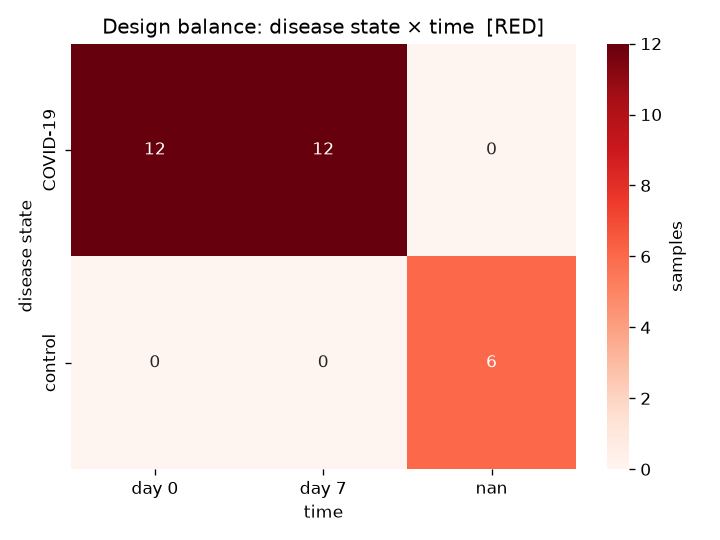

In [8]:
display(Image("design_balance.png"))

## Step 4 — PCA colored by factor — NOT EXERCISED

Step 4 requires an **expression matrix** (`X = samples x genes`), which this metadata-only
fixture (`sample_metadata.csv`) does not provide. Per the recipe's own instruction
("**Skip this step if you only have the metadata table**"), Step 4 is not run here and
`pca_by_factor.png` is not produced. Validating Step 4 requires a separate expression fixture.